In [1]:
import bayesian_optimization as bo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import comb
from scipy.stats import norm
import seaborn as sns
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel,
)
sns.set()
import pickle
from scipy.stats import wilcoxon, ttest_rel
from scipy.stats import wilcoxon, friedmanchisquare

# Simulation Experiment in Section 6.1

## Part 1: Function Gallaries + Config


In [2]:
#-----------------Batch One ------------------------------------------------------------------#

def sphere_nd(x, dim=None):
    """N-dimensional sphere function: global optimum at center with value 0"""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Rescale from [0,1] to [-5,5]
    u = 10 * x - 5
    value = np.sum(u**2, axis=1)
    return -value

def rosenbrock_nd(x, dim=None):
    """N-dimensional Rosenbrock function"""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Rescale from [0,1] to [-2,2] 
    u = 4 * x - 2
    
    if u.shape[1] == 1:
        return -np.ones(u.shape[0])  # Degenerate case
    
    value = np.zeros(u.shape[0])
    for i in range(u.shape[1] - 1):
        value += 100 * (u[:, i+1] - u[:, i]**2)**2 + (1 - u[:, i])**2
    return -value


def ackley_nd(x, dim=None):
    """N-dimensional Ackley function"""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Rescale from [0,1] to [-5,5]
    u = 10 * x - 5
    
    n = u.shape[1]
    term1 = -20 * np.exp(-0.2 * np.sqrt(np.sum(u**2, axis=1) / n))
    term2 = -np.exp(np.sum(np.cos(2*np.pi*u), axis=1) / n)
    value = term1 + term2 + 20 + np.e
    return -value

def rastrigin_nd(x, dim=None):
    """N-dimensional Rastrigin function"""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Rescale from [0,1] to [-5.12,5.12]
    u = 10.24 * x - 5.12
    
    A = 10
    n = u.shape[1]
    value = A * n + np.sum(u**2 - A * np.cos(2*np.pi*u), axis=1)
    return -value

def schwefel_nd(x, dim=None):
    """N-dimensional Schwefel function (highly multimodal)"""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Rescale from [0,1] to [-500,500]
    u = 1000 * x - 500
    
    n = u.shape[1]
    value = 418.9829 * n - np.sum(u * np.sin(np.sqrt(np.abs(u))), axis=1)
    return -value

def levy_nd(x, dim=None):
    """N-dimensional Levy function"""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Rescale from [0,1] to [-10,10]
    u = 20 * x - 10
    
    w = 1 + (u - 1) / 4
    
    term1 = np.sin(np.pi * w[:, 0])**2
    
    if u.shape[1] > 1:
        term2 = np.sum((w[:, :-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:, :-1] + 1)**2), axis=1)
        term3 = (w[:, -1] - 1)**2 * (1 + np.sin(2 * np.pi * w[:, -1])**2)
    else:
        term2 = 0
        term3 = 0
    
    value = term1 + term2 + term3
    return -value


def zakharov_nd(x, dim=None):
    """Zakharov (nD). Domain: [-5,10]^d. Global min 0 at u=0 ⇒ x* = 1/3."""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1: x = x.reshape(1, -1)
    u = 15.0 * x - 5.0
    d = u.shape[1]
    i = np.arange(1, d + 1, dtype=float)
    s1 = np.sum(u**2, axis=1)
    s2 = np.sum(0.5 * i * u, axis=1)
    value = s1 + s2**2 + s2**4
    return -value  # max = 0 at x = 1/3 * 1

def griewank_nd(x, dim=None):
    """Griewank (nD). Domain: [-600,600]^d. Global min 0 at u=0 ⇒ x* = 0.5."""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1: x = x.reshape(1, -1)
    u = 1200.0 * x - 600.0
    d = u.shape[1]
    i = np.sqrt(np.arange(1, d + 1, dtype=float))
    sum_term = np.sum(u**2, axis=1) / 4000.0
    prod_term = np.prod(np.cos(u / i), axis=1)
    value = 1.0 + sum_term - prod_term
    return -value  # max = 0 at x = 0.5 * 1

def sum_different_powers_nd(x, dim=None):
    """Sum of Different Powers. Domain: [-1,1]. Global min 0 at u=0 ⇒ x* = 0.5."""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    # Linear rescaling [0,1]^d → [-10, 10]^d
    u = 20.0 * x - 10.0
    d = u.shape[1]
    i = np.arange(1, d + 1, dtype=float)  # weights 1..d
    value = np.sum(i * (u**2), axis=1)
    return -value  # maximize this; max =0

def alpine1_nd(x, dim=None):   
    """Alpine 1 (nD). Domain: [0,10]^d. Global min 0 at u=0 ⇒ x* = 0 (boundary, still in [0,1]^d)."""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1: x = x.reshape(1, -1)
    u = 10.0 * x  # [0,10]^d
    value = np.sum(np.abs(u * np.sin(u) + 0.1 * u), axis=1)
    return -value  # max = 0 at x = 0 * 1

def expanded_scaffer_f6_nd(x, dim=None):
    """Expanded Scaffer F6 (nD, cyclic pairs). Domain: [-100,100]^d. Global min 0 at u=0 ⇒ x* = 0.5."""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1: x = x.reshape(1, -1)
    u = 200.0 * x - 100.0
    # pairwise with wrap-around
    v = np.roll(u, shift=-1, axis=1)
    r2 = u**2 + v**2
    term = 0.5 + (np.sin(np.sqrt(r2))**2 - 0.5) / (1.0 + 0.001 * r2)**2
    value = np.sum(term, axis=1)
    return -value  # max = 0 at x = 0.5 * 1

FUNCTIONS = {
    'sphere': {'func': sphere_nd, 'optimum': 0.0, 'description': 'Convex, unimodal'},
    'rosenbrock': {'func': rosenbrock_nd, 'optimum': 0.0, 'description': 'Non-convex, valley'},
    'ackley': {'func': ackley_nd, 'optimum': 0.0, 'description': 'Highly multimodal'},
    'rastrigin': {'func': rastrigin_nd, 'optimum': 0.0, 'description': 'Many local minima'},
    'schwefel': {'func': schwefel_nd, 'optimum': 0.0, 'description': 'Deceptive, multimodal'},
    'levy': {'func': levy_nd, 'optimum': 0.0, 'description': 'Multimodal, steep ridges'},
    'zakharov': {'func': zakharov_nd,'optimum': 0.0,'description': 'Bowl + coupling term; non-separable, unimodal-ish'},
    'griewank': {'func': griewank_nd, 'optimum': 0.0, 'description': 'Weakly multimodal; widespread shallow local minima'},
    'alpine1': {'func': alpine1_nd,'optimum': 0.0,'description': 'Non-convex, multimodal (sine); optimum on boundary'},
    'expanded_scaffer_f6': {'func': expanded_scaffer_f6_nd,'optimum': 0.0,'description': 'Highly multimodal; cyclic pairwise non-separability'}
}



#-----------------Batch Two ------------------------------------------------------------------#


def bukin6_2d(x, dim=None):
    """Bukin function N.6 (2D). 2D only
    Domain (native): x1 ∈ [-15, -5], x2 ∈ [-3, 3]
    Global minimum: f(-10, 1) = 0  → after rescaling, argmax at x = (0.5, 2/3)
    Returns negative value so max = 0 at the optimum.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Bukin N.6 is 2D; expected x with 2 columns.")

    # Linear rescaling from [0,1]^2 to native domain
    u1 = -15.0 + 10.0 * x[:, 0]   # [-15, -5]
    u2 = -3.0  +  6.0 * x[:, 1]   # [-3, 3]

    term1 = 100.0 * np.sqrt(np.abs(u2 - 0.01 * u1**2))
    term2 = 0.01 * np.abs(u1 + 10.0)
    value = term1 + term2
    return -value  # maximum 0 at x* = (0.5, 2/3)


def cross_in_tray_2d(x, dim=None):
    """Cross-in-Tray (2D).
    Native domain: u1,u2 ∈ [-10, 10], 2D only
    Native global minima: f(u*) ≈ -2.06261218 at (±1.34941, ±1.34941)
    We rescale from [0,1]^2 and shift so the returned objective has max = 0 at the minima.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Cross-in-Tray is 2D; expected x with 2 columns.")

    # Linear rescaling from [0,1]^2 → [-10,10]^2
    u1 = 20.0 * x[:, 0] - 10.0
    u2 = 20.0 * x[:, 1] - 10.0

    # Native Cross-in-Tray value (negative near minima)
    fact1 = np.sin(u1) * np.sin(u2)
    r = np.sqrt(u1**2 + u2**2)
    fact2 = np.exp(np.abs(100.0 - r / np.pi))
    f_native = -0.0001 * (np.abs(fact1 * fact2) + 1.0) ** 0.1

    # Shift so the minimum becomes 0, then negate → maximum = 0 at the global minimizers
    f_min = -2.06261218  # known global minimum value
    value = f_native - f_min
    return -value

def drop_wave_nd(x, dim=None):
    """Drop-Wave (nD).
    Native domain: u_j ∈ [-5.12, 5.12]
    Native global minimum: f(u)= - (1 + cos(12*||u||)) / (0.5*||u||^2 + 2), minimized at u=0 with f_min = -1.
    We rescale from [0,1]^d and shift so the returned objective has max = 0 at the minimum.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    u = 10.24 * x - 5.12  # linear rescaling [0,1]^d -> [-5.12, 5.12]^d

    r = np.linalg.norm(u, axis=1)
    f_native = - (1.0 + np.cos(12.0 * r)) / (0.5 * r**2 + 2.0)  # ≤ -1, with min -1 at u=0
    value = f_native + 1.0  # shift so min becomes 0
    return -value           # -> maximum 0 at x* = 0.5·1


def eggholder_2d(x, dim=None):
    """Eggholder (2D).
    Native domain: u1,u2 ∈ [-512, 512]
    Native global minimum: f(512, 404.2319) ≈ -959.6406627
    We rescale from [0,1]^2 and shift so the returned objective has max = 0 at the minimum.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Eggholder is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-512, 512]^2
    u1 = 1024.0 * x[:, 0] - 512.0
    u2 = 1024.0 * x[:, 1] - 512.0

    term1 = -(u2 + 47.0) * np.sin(np.sqrt(np.abs(u2 + (u1 / 2.0) + 47.0)))
    term2 = -u1 * np.sin(np.sqrt(np.abs(u1 - (u2 + 47.0))))
    f_native = term1 + term2

    # Shift so the minimum becomes 0, then negate → maximum = 0 at the global minimizer
    f_min = -959.640662711  # known global minimum value
    value = f_native - f_min
    return -value  # argmax occurs at x* ≈ ((512+512)/1024, (404.2319+512)/1024) ≈ (1.0, 0.895)


def grlee12_nd(x, dim=None):
    """Gramacy & Lee (2012) — nD separable extension.
    Each coordinate u_j ∈ [0.5, 2.5], f_nd(u) = Σ_j [sin(10πu_j)/(2u_j) + (u_j-1)^4]
    The per-dimension minimum is f_min_1d; global minimum is d * f_min_1d at u_j = u* ∀j.
    Returns: -(f_nd(u) - d*f_min_1d) so the returned maximum is 0 at the minimizer.
    ND status: The canonical benchmark is 1D; this is a common separable nD extension.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # Linear rescaling [0,1]^d -> [0.5, 2.5]^d
    u = 2.0 * x + 0.5  # shape (n, d)
    # Evaluate per-dim and sum
    f_per_dim = np.sin(10.0 * np.pi * u) / (2.0 * u) + (u - 1.0) ** 4
    f_native = np.sum(f_per_dim, axis=1)

    d = u.shape[1]
    f_min_1d = -0.8690111349895001
    value = f_native - d * f_min_1d
    return -value  # maximum 0 at x* = ((u* - 0.5)/2) * 1_d  (~0.02428 on each coord)

def holder_table_2d(x, dim=None):
    """Hölder Table (2D).
    Native domain: u1,u2 ∈ [-10, 10]
    Native global minima: f(u*) ≈ -19.20850257 at (±8.05502, ±9.66459) (four points)
    We rescale from [0,1]^2 and shift so the returned objective has max = 0 at the minima.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Hölder Table is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-10, 10]^2
    u1 = 20.0 * x[:, 0] - 10.0
    u2 = 20.0 * x[:, 1] - 10.0

    fact1 = np.sin(u1) * np.cos(u2)
    r = np.sqrt(u1**2 + u2**2)
    fact2 = np.exp(np.abs(1.0 - r / np.pi))
    f_native = -np.abs(fact1 * fact2)

    # Shift so the minimum becomes 0, then negate → maximum = 0 at the global minimizers
    f_min = -19.2085025679
    value = f_native - f_min
    return -value

    

def levy13_2d(x, dim=None):
    """Levy N.13 (2D, canonical).
    Native domain: u1,u2 ∈ [-10, 10]
    Global minimum: f(1,1) = 0
    Returns: -f(u) so the maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Levy N.13 is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-10,10]^2
    u1 = 20.0 * x[:, 0] - 10.0
    u2 = 20.0 * x[:, 1] - 10.0

    term1 = np.sin(3.0 * np.pi * u1) ** 2
    term2 = (u1 - 1.0) ** 2 * (1.0 + np.sin(3.0 * np.pi * u2) ** 2)
    term3 = (u2 - 1.0) ** 2 * (1.0 + np.sin(2.0 * np.pi * u2) ** 2)
    f = term1 + term2 + term3
    return -f  # max 0 at (u1,u2)=(1,1) → x*=(0.55, 0.55)


def schaffer2_2d(x, dim=None):
    """Schaffer N.2 (2D, canonical).
    Native domain: u1,u2 ∈ [-100, 100]
    f(u) = 0.5 + (sin^2(u1^2 - u2^2) - 0.5) / (1 + 0.001*(u1^2 + u2^2))^2
    Global minimum: f(0,0) = 0
    Returns: -f(u) so the maximum is 0 at the minimizer.
    ND status: 2D ONLY (no standard n-D), see schaffer2_nd for an expanded n-D version.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Schaffer N.2 is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-100, 100]^2
    u1 = 200.0 * x[:, 0] - 100.0
    u2 = 200.0 * x[:, 1] - 100.0

    num = np.sin(u1**2 - u2**2)**2 - 0.5
    den = (1.0 + 0.001 * (u1**2 + u2**2))**2
    f_native = 0.5 + num / den
    return -f_native  # max 0 at x* = (0.5, 0.5)

def schaffer4_2d(x, dim=None):
    """Schaffer N.4 (2D).
    Native domain: u1,u2 ∈ [-100, 100]
    f(u) = 0.5 + (cos^2(sin(|u1^2 - u2^2|)) - 0.5) / (1 + 0.001*(u1^2 + u2^2))**2
    Global minimum ≈ 0.292579 (various symmetric locations).
    Returns: -(f(u) - f_min) so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Schaffer N.4 is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-100, 100]^2
    u1 = 200.0 * x[:, 0] - 100.0
    u2 = 200.0 * x[:, 1] - 100.0

    num = (np.cos(np.sin(np.abs(u1**2 - u2**2)))**2) - 0.5
    den = (1.0 + 0.001 * (u1**2 + u2**2))**2
    f_native = 0.5 + num / den

    f_min = 0.292579  # known global minimum (approx.)
    return -(f_native - f_min)


def shubert_2d(x, dim=None):
    """Shubert function (2D).
    Native domain: u1,u2 ∈ [-10, 10]
    f(u) = [Σ_{i=1}^5 i cos((i+1)u1 + i)] * [Σ_{i=1}^5 i cos((i+1)u2 + i)]
    Known global minimum ≈ -186.7309088 at multiple points.
    Returns: -(f(u) - f_min) so the returned maximum is 0 at any global minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Shubert is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-10, 10]^2
    u1 = 20.0 * x[:, 0] - 10.0
    u2 = 20.0 * x[:, 1] - 10.0

    i = np.arange(1, 6, dtype=float)                 # 1..5
    sum1 = np.sum(i * np.cos((i + 1) * u1[:, None] + i), axis=1)
    sum2 = np.sum(i * np.cos((i + 1) * u2[:, None] + i), axis=1)
    f_native = sum1 * sum2

    f_min = -186.7309088  # widely reported global minimum
    return -(f_native - f_min)  # => max = 0 at global minima

def bohachevsky1_2d(x, dim=None):
    """Bohachevsky Function 1 (2D).
    Native domain: u1,u2 ∈ [-100, 100]
    f(u) = u1^2 + 2 u2^2 - 0.3 cos(3π u1) - 0.4 cos(4π u2) + 0.7
    Global minimum: f(0,0) = 0  → after negation, returned max is 0 at x* = (0.5, 0.5).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Bohachevsky 1 is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-100, 100]^2
    u1 = 200.0 * x[:, 0] - 100.0
    u2 = 200.0 * x[:, 1] - 100.0

    f_native = (u1**2
                + 2.0 * (u2**2)
                - 0.3 * np.cos(3.0 * np.pi * u1)
                - 0.4 * np.cos(4.0 * np.pi * u2)
                + 0.7)

    return -f_native  # maximize this; max = 0 at (u1,u2)=(0,0) → x=(0.5,0.5)



def rotated_hyper_ellipsoid_nd(x, dim=None):
    """Rotated Hyper-Ellipsoid (nD).
    Native domain: u_j ∈ [-65.536, 65.536]
    f(u) = Σ_{i=1}^d Σ_{j=1}^i u_j^2  (a.k.a. cumulative sum of squares)
    Global minimum: f(0)=0  → after negation, returned max is 0 at x* = 0.5·1_d.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # Linear rescaling [0,1]^d → [-65.536, 65.536]^d
    u = 131.072 * x - 65.536

    # f(u) = sum over i of prefix sums of u^2
    prefix = np.cumsum(u**2, axis=1)
    value = np.sum(prefix, axis=1)
    return -value


def sum_squares_nd(x, dim=None):
    """Sum Squares (nD).
    Native domain: u_j ∈ [-10, 10]
    f(u) = Σ_{j=1}^d j * u_j^2
    Global minimum: f(0)=0 → after negation, returned max is 0 at x* = 0.5·1_d.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # Linear rescaling [0,1]^d → [-10, 10]^d
    u = 20.0 * x - 10.0
    d = u.shape[1]

    i = np.arange(1, d + 1, dtype=float)  # weights 1..d
    value = np.sum(i * (u**2), axis=1)
    return -value

def trid_nd(x, dim=None):
    """TRID (nD).
    Native domain: u_j ∈ [-d^2, d^2]
    f(u) = Σ_{j=1}^d (u_j - 1)^2 - Σ_{j=2}^d u_j u_{j-1}
    Global minimum: f(u*) = -d(d+4)(d-1)/6 at u*_j = j (d + 1 - j)
    Returns: -(f(u) - f_min) so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    n, d = x.shape
    if d < 1:
        raise ValueError("Input must have at least one dimension.")

    # Linear rescaling [0,1]^d → [-d^2, d^2]^d
    u = 2.0 * (d ** 2) * x - (d ** 2)

    # f(u) = sum (u_j - 1)^2 - sum u_j u_{j-1}
    sum1 = np.sum((u - 1.0) ** 2, axis=1)
    if d == 1:
        f_native = sum1
    else:
        sum2 = np.sum(u[:, 1:] * u[:, :-1], axis=1)
        f_native = sum1 - sum2

    # Known global minimum value
    f_min = - (d * (d + 4) * (d - 1)) / 6.0

    return -(f_native - f_min)  # ⇒ maximum 0 at u*_j = j(d+1-j)


def booth_2d(x, dim=None):
    """Booth function (2D).
    Native domain: u1,u2 ∈ [-10, 10]
    f(u) = (u1 + 2u2 - 7)^2 + (2u1 + u2 - 5)^2
    Global minimum: f(1,3) = 0  → after negation, returned max is 0 at x* = ((1+10)/20, (3+10)/20) = (0.55, 0.65).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Booth is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-10, 10]^2
    u1 = 20.0 * x[:, 0] - 10.0
    u2 = 20.0 * x[:, 1] - 10.0

    f_native = (u1 + 2.0 * u2 - 7.0) ** 2 + (2.0 * u1 + u2 - 5.0) ** 2
    return -f_native  # maximize this; max = 0 at (u1,u2)=(1,3) → x=(0.55,0.65)


def matyas_2d(x, dim=None):
    """Matyas function (2D).
    Native domain: u1,u2 ∈ [-10, 10]
    f(u) = 0.26*(u1^2 + u2^2) - 0.48*u1*u2
    Global minimum: f(0,0)=0 → after negation, returned max is 0 at x* = (0.5, 0.5).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Matyas is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-10, 10]^2
    u1 = 20.0 * x[:, 0] - 10.0
    u2 = 20.0 * x[:, 1] - 10.0

    f_native = 0.26 * (u1**2 + u2**2) - 0.48 * u1 * u2
    return -f_native  # maximize this; max = 0 at (u1,u2)=(0,0) → x=(0.5,0.5)


def mccormick_2d(x, dim=None):
    """McCormick function (2D).
    Native domain: u1 ∈ [-1.5, 4], u2 ∈ [-3, 4]
    f(u) = sin(u1 + u2) + (u1 - u2)^2 - 1.5*u1 + 2.5*u2 + 1
    Known global minimum ≈ -1.913222954981 at (u1,u2) ≈ (-0.54719, -1.54719).
    Returns: -(f(u) - f_min) so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("McCormick is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-1.5,4] × [-3,4]
    u1 = -1.5 + 5.5 * x[:, 0]  # [-1.5, 4]
    u2 = -3.0 + 7.0 * x[:, 1]  # [-3, 4]

    f_native = (
        np.sin(u1 + u2)
        + (u1 - u2) ** 2
        - 1.5 * u1
        + 2.5 * u2
        + 1.0
    )

    f_min = -1.913222954981  # reported global minimum
    return -(f_native - f_min)  # ⇒ max = 0 at the global minimizer

def power_sum_4d(x, dim=None, b=(8.0, 18.0, 44.0, 114.0)):
    """Power Sum (fixed 4D).
    Input: x ∈ [0,1]^4  → rescale to u = 4 * x ∈ [0,4]^4
    f(u) = Σ_{i=1}^4 ( Σ_{j=1}^4 u_j^i  -  b_i )^2
    Returns: -f(u) so the maximum is 0 when the moment constraints are met.

    Notes
    -----
    - Fixed dimensionality: 4D only.
    - 'dim' is accepted for API consistency; if provided, it must be 4.
    - 'b' defaults to the common benchmark vector (8, 18, 44, 114).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    n, d = x.shape
    if d != 4:
        raise ValueError(f"power_sum_4d expects 4 columns, got d={d}")
    if dim is not None and dim != 4:
        raise ValueError(f"dim must be 4 for power_sum_4d, got dim={dim}")

    b_vec = np.asarray(b, dtype=float)
    if b_vec.shape != (4,):
        raise ValueError("b must be length-4 (default: (8, 18, 44, 114))")

    # Rescale [0,1]^4 → [0,4]^4
    u = 4.0 * x  # (n, 4)

    # inner_i = sum_j u_j^i, for i = 1..4
    i = np.arange(1, 5, dtype=float)            # (4,)
    u_pow = u[:, None, :] ** i[:, None]         # (n, 4, 4) axis=1 indexes i
    inner = np.sum(u_pow, axis=2)               # (n, 4)

    diff = inner - b_vec[None, :]               # (n, 4)
    value = np.sum(diff**2, axis=1)             # (n,)

    return -value  # max = 0 when inner == b



FUNCTIONS_Batch2 = {
    'bukin6': {
        'func': bukin6_2d,
        'optimum': 0.0,
        'description': '2D only; steep valley with ridges',
        'dim': 2,
    },
    'cross_in_tray': {
        'func': cross_in_tray_2d,
        'optimum': 0.0,
        'description': '2D only; highly multimodal with 4 symmetric minima',
        'dim': 2,
    },
    'drop_wave': {
        'func': drop_wave_nd,
        'optimum': 0.0,
        'description': 'Radial ripples; many local minima (nD)',
        'dim': None,
    },
    'eggholder': {
        'func': eggholder_2d,
        'optimum': 0.0,
        'description': '2D only; very rugged landscape',
        'dim': 2,
    },
    'grlee12': {
        'func': grlee12_nd,
        'optimum': 0.0,
        'description': 'Separable oscillatory extension of GL(2012); sharp around u≈0.55 (nD)',
        'dim': None,
    },
    'holder_table': {
        'func': holder_table_2d,
        'optimum': 0.0,
        'description': '2D only; rugged with four symmetric minima',
        'dim': 2,
    },
    'levy13': {
        'func': levy13_2d,
        'optimum': 0.0,
        'description': '2D only; multimodal, minimum at (1,1)',
        'dim': 2,
    },
    'schaffer2': {
        'func': schaffer2_2d,
        'optimum': 0.0,
        'description': '2D only; oscillatory cliffs, minimum at origin',
        'dim': 2,
    },
    'schaffer4': {
        'func': schaffer4_2d,
        'optimum': 0.0,
        'description': '2D only; oscillatory, shallow basin (shifted)',
        'dim': 2,
    },
    'shubert': {
        'func': shubert_2d,
        'optimum': 0.0,
        'description': '2D only; many symmetric minima',
        'dim': 2,
    },
    'bohachevsky1': {
        'func': bohachevsky1_2d,
        'optimum': 0.0,
        'description': '2D only; quadratic with cosine ripples',
        'dim': 2,
    },
    'rotated_hyper_ellipsoid': {
        'func': rotated_hyper_ellipsoid_nd,
        'optimum': 0.0,
        'description': 'Non-separable cumulative sum of squares (nD)',
        'dim': None,
    },
    'sum_squares': {
        'func': sum_squares_nd,
        'optimum': 0.0,
        'description': 'Separable quadratic with increasing weights (nD)',
        'dim': None,
    },
    'booth': {
        'func': booth_2d,
        'optimum': 0.0,
        'description': '2D only; quadratic with unique minimum at (1,3)',
        'dim': 2,
    },
    'matyas': {
        'func': matyas_2d,
        'optimum': 0.0,
        'description': '2D only; quadratic with cross term',
        'dim': 2,
    },
    'mccormick': {
        'func': mccormick_2d,
        'optimum': 0.0,
        'description': '2D only; non-convex with curved valley',
        'dim': 2,
    },
    'power_sum': {
        'func': power_sum_4d,
        'optimum': 0.0,
        'description': 'Moment-matching objective parameterized by b (nD)',
        'dim': 4,
    },
}


#-----------------Batch Three ------------------------------------------------------------------#

def camel3_2d(x, dim=None):
    """Three-Hump Camel (2D).
    Native domain: u1,u2 ∈ [-5, 5]
    f(u) = 2u1^2 - 1.05u1^4 + (u1^6)/6 + u1*u2 + u2^2
    Global minimum: f(0,0) = 0  → after negation, returned max is 0 at x* = (0.5, 0.5).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Three-Hump Camel is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-5, 5]^2
    u1 = 10.0 * x[:, 0] - 5.0
    u2 = 10.0 * x[:, 1] - 5.0

    f_native = 2.0 * u1**2 - 1.05 * u1**4 + (u1**6) / 6.0 + u1 * u2 + u2**2
    return -f_native


def camel6_2d(x, dim=None):
    """Six-Hump Camel (2D).
    Native domain: u1 ∈ [-3, 3], u2 ∈ [-2, 2]
    f(u) = (4 - 2.1*u1^2 + (u1^4)/3) * u1^2 + u1*u2 + (-4 + 4*u2^2) * u2^2
    Global minima ≈ f(u*) = -1.03162845349 at (±0.089842, ∓0.712656).
    Returns: -(f(u) - f_min) so the returned maximum is 0 at the minimizers.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Six-Hump Camel is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-3,3] × [-2,2]
    u1 = 6.0 * x[:, 0] - 3.0   # [-3, 3]
    u2 = 4.0 * x[:, 1] - 2.0   # [-2, 2]

    f_native = ((4.0 - 2.1 * u1**2 + (u1**4) / 3.0) * u1**2
                + u1 * u2
                + (-4.0 + 4.0 * u2**2) * u2**2)

    f_min = -1.0316284534898772  # known global minimum
    return -(f_native - f_min)



def dixon_price_nd(x, dim=None):
    """Dixon–Price (nD).
    Native domain: u_j ∈ [-10, 10]
    f(u) = (u1 - 1)^2 + Σ_{i=2}^d i * (2*u_i^2 - u_{i-1})^2
    Global minimum: f(u*) = 0 (achieved at a known closed-form u*); we return -f(u) so max = 0.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # Rescale [0,1]^d → [-10,10]^d
    u = 20.0 * x - 10.0
    d = u.shape[1]

    term1 = (u[:, 0] - 1.0) ** 2
    if d == 1:
        value = term1
    else:
        i = np.arange(2, d + 1, dtype=float)  # 2..d
        value = term1 + np.sum(i * (2.0 * u[:, 1:]**2 - u[:, :-1])**2, axis=1)
    return -value

def dejong5_2d(x, dim=None):
    """De Jong function N.5 (2D, 'Shekel's Foxholes').
    Native domain: u1,u2 ∈ [-65.536, 65.536]
    f(u) = 1 / ( 0.002 + Σ_{i=1}^{25} 1 / ( i + (u1 - A1_i)^6 + (u2 - A2_i)^6 ) )
    Global minimum ≈ 0.9980038378 at u* ≈ (-32, -32) and other grid points.
    Returns: -(f(u) - f_min) so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("De Jong N.5 is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-65.536, 65.536]^2
    u1 = 131.072 * x[:, 0] - 65.536
    u2 = 131.072 * x[:, 1] - 65.536

    # Grid A (2 x 25) with coordinates from {-32,-16,0,16,32}
    a = np.array([-32., -16., 0., 16., 32.])
    A1 = np.repeat(a, 5)  # shape (25,)
    A2 = np.tile(a, 5)    # shape (25,)

    i = np.arange(1, 26, dtype=float)  # 1..25

    # Compute Σ 1 / (i + (u1 - A1_i)^6 + (u2 - A2_i)^6) per sample
    du1 = (u1[:, None] - A1[None, :]) ** 6
    du2 = (u2[:, None] - A2[None, :]) ** 6
    denom_inner = i[None, :] + du1 + du2
    S = np.sum(1.0 / denom_inner, axis=1)

    f_native = 1.0 / (0.002 + S)

    # Known global minimum value (literature)
    f_min = 0.998003837794  # ~ at (-32, -32) etc.
    return -(f_native - f_min)


def easom_2d(x, dim=None):
    """Easom (2D).
    Native domain: u1,u2 ∈ [-100, 100]
    f(u) = -cos(u1)*cos(u2)*exp(-((u1-π)^2 + (u2-π)^2))
    Global minimum: f(π, π) = -1.
    We return -(f + 1) so the returned maximum is 0 at (π, π).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Easom is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-100, 100]^2
    u1 = 200.0 * x[:, 0] - 100.0
    u2 = 200.0 * x[:, 1] - 100.0

    f_native = -np.cos(u1) * np.cos(u2) * np.exp(-((u1 - np.pi)**2 + (u2 - np.pi)**2))
    value = f_native + 1.0  # shift so min becomes 0
    return -value           # => max = 0 at (u1,u2) = (π, π)


def michalewicz_nd(x, dim=None, m=10, f_min=None):
    """Michalewicz (nD).
    Native domain: u_j ∈ [0, π]
    f(u) = - Σ_{j=1}^d [ sin(u_j) * ( sin(j * u_j^2 / π) )^(2m) ]
    The landscape becomes more rugged with larger m.
    If f_min is provided (known global minimum value), returns -(f - f_min) so max = 0 at the minimizer.
    Otherwise returns -f(u) (still maximization, but not anchored to 0).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # Rescale [0,1]^d → [0, π]^d
    u = np.pi * x
    d = u.shape[1]
    j = np.arange(1, d + 1, dtype=float)[None, :]   # shape (1, d) for broadcasting

    terms = np.sin(u) * (np.sin((j * (u**2)) / np.pi)) ** (2.0 * m)
    f_native = -np.sum(terms, axis=1)

    if f_min is not None:
        return -(f_native - f_min)  # max = 0 at global minimizer
    return -f_native


def beale_2d(x, dim=None):
    """Beale function (2D).
    Native domain: u1,u2 ∈ [-4.5, 4.5]
    f(u) = (1.5 - u1 + u1*u2)^2 + (2.25 - u1 + u1*u2^2)^2 + (2.625 - u1 + u1*u2^3)^2
    Global minimum: f(3, 0.5) = 0  → after negation, returned max is 0 at x* = ((3+4.5)/9, (0.5+4.5)/9).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Beale is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-4.5, 4.5]^2
    u1 = 9.0 * x[:, 0] - 4.5
    u2 = 9.0 * x[:, 1] - 4.5

    f_native = ((1.5   - u1 + u1 * u2)    ** 2 +
                (2.25  - u1 + u1 * u2**2) ** 2 +
                (2.625 - u1 + u1 * u2**3) ** 2)

    return -f_native


def branin_2d(x, dim=None, a=1.0, b=5.1/(4*np.pi**2), c=5/np.pi, r=6.0, s=10.0, t=1/(8*np.pi)):
    """Branin (2D).
    Native domain: u1 ∈ [-5, 10], u2 ∈ [0, 15]
    f(u) = a*(u2 - b*u1^2 + c*u1 - r)^2 + s*(1 - t)*cos(u1) + s
    Global minima value (standard params): f_min ≈ 0.39788735772973816 at three points.
    Returns: -(f(u) - f_min) so the returned maximum is 0 at any global minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Branin is 2D; expected x with 2 columns.")

    # Linear rescaling [0,1]^2 → [-5,10] × [0,15]
    u1 = 15.0 * x[:, 0] - 5.0
    u2 = 15.0 * x[:, 1] - 0.0

    f_native = a * (u2 - b * u1**2 + c * u1 - r)**2 + s * (1.0 - t) * np.cos(u1) + s

    # Standard-parameter global minimum
    f_min = 0.39788735772973816
    return -(f_native - f_min)

def colville_4d(x, dim=None):
    """Colville function (4D).
    Native domain: u1..u4 ∈ [-10, 10]
    f(u) = 100(u1^2 - u2)^2 + (u1 - 1)^2 + (u3 - 1)^2
           + 90(u3^2 - u4)^2 + 10.1[(u2 - 1)^2 + (u4 - 1)^2]
           + 19.8(u2 - 1)(u4 - 1)
    Global minimum: f(1,1,1,1) = 0 → after negation, returned max is 0 at x* = (0.55,0.55,0.55,0.55).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 4:
        raise ValueError("Colville is 4D; expected x with 4 columns.")

    # Rescale [0,1]^4 → [-10, 10]^4
    u = 20.0 * x - 10.0
    u1, u2, u3, u4 = u[:, 0], u[:, 1], u[:, 2], u[:, 3]

    f_native = (
        100.0 * (u1**2 - u2)**2
        + (u1 - 1.0)**2
        + (u3 - 1.0)**2
        + 90.0 * (u3**2 - u4)**2
        + 10.1 * ((u2 - 1.0)**2 + (u4 - 1.0)**2)
        + 19.8 * (u2 - 1.0) * (u4 - 1.0)
    )
    return -f_native

def forretal08_1d(x, dim=None):
    """Forrester et al. (2008) — 1D.
    Native domain: u ∈ [0, 1]
    f(u) = (6u - 2)^2 * sin(12u - 4)
    Global minimum (this variant): f_min ≈ -6.020740055735768 at u* ≈ 0.757249
    Returns: -(f(u) - f_min) so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 1:
        raise ValueError("Forrester 2008 is 1D; expected x with 1 column.")

    # Rescale [0,1] → [0,1] (identity, shown for consistency)
    u = x[:, 0]

    f_native = (6.0 * u - 2.0) ** 2 * np.sin(12.0 * u - 4.0)

    f_min = -6.020740055735768  # numeric (global) minimum on [0,1]
    return -(f_native - f_min)

def goldstein_price_2d(x, dim=None):
    """Goldstein–Price (2D).
    Native domain: u1,u2 ∈ [-2, 2]
    Global minimum: f(0, -1) = 3
    Returns: -(f(u) - 3) so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 2:
        raise ValueError("Goldstein–Price is 2D; expected x with 2 columns.")

    # Rescale [0,1]^2 → [-2, 2]^2
    u1 = 4.0 * x[:, 0] - 2.0
    u2 = 4.0 * x[:, 1] - 2.0

    fact1a = (u1 + u2 + 1.0) ** 2
    fact1b = 19.0 - 14.0*u1 + 3.0*u1**2 - 14.0*u2 + 6.0*u1*u2 + 3.0*u2**2
    fact1  = 1.0 + fact1a * fact1b

    fact2a = (2.0*u1 - 3.0*u2) ** 2
    fact2b = 18.0 - 32.0*u1 + 12.0*u1**2 + 48.0*u2 - 36.0*u1*u2 + 27.0*u2**2
    fact2  = 30.0 + fact2a * fact2b

    f_native = fact1 * fact2
    f_min = 3.0
    return -(f_native - f_min)


def hartmann3_3d(x, dim=None, f_min=None):
    """Hartmann 3D (fixed 3D).
    Domain: u ∈ [0,1]^3
    Native form: f(u) = - Σ_{k=1}^4 α_k * exp( - Σ_{j=1}^3 A[k,j] * (u_j - P[k,j])^2 )
    If f_min is provided, returns -(f - f_min) so the maximum is 0 at the global minimizer.
    Otherwise returns -f(u).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 3:
        raise ValueError("Hartmann-3D is fixed 3D; expected x with 3 columns.")

    # Native parameters
    alpha = np.array([1.0, 1.2, 3.0, 3.2], dtype=float)
    A = np.array([
        [3.0, 10.0, 30.0],
        [0.1, 10.0, 35.0],
        [3.0, 10.0, 30.0],
        [0.1, 10.0, 35.0]
    ], dtype=float)
    P = 1e-4 * np.array([
        [3689, 1170, 2673],
        [4699, 4387, 7470],
        [1091, 8732, 5547],
        [ 381, 5743, 8828]
    ], dtype=float)

    # u = x in this case (domain is [0,1]^3)
    u = x

    # inner_k = sum_j A[k,j] * (u_j - P[k,j])^2
    diff = u[:, None, :] - P[None, :, :]          # (n, 4, 3)
    inner = np.sum(A[None, :, :] * diff**2, axis=2)  # (n, 4)

    f_native = -np.sum(alpha[None, :] * np.exp(-inner), axis=1)  # (n,)

    if f_min is not None:
        return -(f_native - f_min)  # anchor so max=0 at the minimizer
    return -f_native

def hartmann4_4d(x, dim=None, f_min=None):
    """Hartmann 4D (fixed 4D).
    Domain: u ∈ [0,1]^4 (no rescaling needed)
    Native form from SFU:
        alpha = [1.0, 1.2, 3.0, 3.2]
        A (4x6), P (4x6); only first 4 columns are used.
        outer = sum_k alpha[k] * exp( - sum_j A[k,j] * (u_j - P[k,j])^2 )
        f_native = (1.1 - outer) / 0.839
    If f_min is provided, returns -(f_native - f_min) to anchor max=0 at the minimizer.
    Otherwise returns -f_native (unanchored; optimum unknown in your registry).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 4:
        raise ValueError("Hartmann-4D is fixed 4D; expected x with 4 columns.")

    alpha = np.array([1.0, 1.2, 3.0, 3.2], dtype=float)

    A = np.array([
        [10.0,  3.0, 17.0,  3.5,  1.7,  8.0],
        [ 0.05,10.0, 17.0,  0.1,  8.0, 14.0],
        [ 3.0,  3.5,  1.7, 10.0, 17.0,  8.0],
        [17.0,  8.0,  0.05,10.0,  0.1, 14.0]
    ], dtype=float)

    P = 1e-4 * np.array([
        [1312, 1696, 5569,  124, 8283, 5886],
        [2329, 4135, 8307, 3736, 1004, 9991],
        [2348, 1451, 3522, 2883, 3047, 6650],
        [4047, 8828, 8732, 5743, 1091,  381]
    ], dtype=float)

    A4 = A[:, :4]  # use first 4 columns
    P4 = P[:, :4]

    u = x  # domain already [0,1]^4

    # inner_k = sum_j A[k,j] * (u_j - P[k,j])^2  for k=1..4
    diff = u[:, None, :] - P4[None, :, :]          # (n, 4, 4)
    inner = np.sum(A4[None, :, :] * diff**2, axis=2)  # (n, 4)

    outer = np.sum(alpha[None, :] * np.exp(-inner), axis=1)
    f_native = (1.1 - outer) / 0.839

    if f_min is not None:
        return -(f_native - f_min)   # anchored: max = 0 at minimizer
    return -f_native              


def hartmann6_6d(x, dim=None, f_min=None):
    """Hartmann 6D (fixed 6D).
    Domain: u ∈ [0,1]^6 (no rescaling)
    Native SFU form:
        alpha = [1.0, 1.2, 3.0, 3.2]
        A (4x6), P (4x6)
        outer = sum_k alpha[k] * exp( - sum_j A[k,j] * (u_j - P[k,j])^2 )
        f_native = -(2.58 + outer) / 1.94
    If f_min is provided, returns -(f_native - f_min) so max = 0 at the minimizer.
    Otherwise returns -f_native (unanchored; treat optimum as unknown in your registry).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 6:
        raise ValueError("Hartmann-6D is fixed 6D; expected x with 6 columns.")

    alpha = np.array([1.0, 1.2, 3.0, 3.2], dtype=float)

    A = np.array([
        [10.0,  3.0, 17.0,  3.5,  1.7,  8.0],
        [ 0.05,10.0, 17.0,  0.1,  8.0, 14.0],
        [ 3.0,  3.5,  1.7, 10.0, 17.0,  8.0],
        [17.0,  8.0,  0.05,10.0,  0.1, 14.0]
    ], dtype=float)

    P = 1e-4 * np.array([
        [1312, 1696, 5569,  124, 8283, 5886],
        [2329, 4135, 8307, 3736, 1004, 9991],
        [2348, 1451, 3522, 2883, 3047, 6650],
        [4047, 8828, 8732, 5743, 1091,  381]
    ], dtype=float)

    u = x  # domain already [0,1]^6

    # inner_k = sum_j A[k,j] * (u_j - P[k,j])^2
    diff = u[:, None, :] - P[None, :, :]            # (n, 4, 6)
    inner = np.sum(A[None, :, :] * diff**2, axis=2) # (n, 4)

    outer = np.sum(alpha[None, :] * np.exp(-inner), axis=1)  # (n,)
    f_native = -(2.58 + outer) / 1.94                       # (n,)

    if f_min is not None:
        return -(f_native - f_min)  # anchored: max = 0 at minimizer
    return -f_native         


def powell_4d(x, dim=None):
    """Powell (quartic) function — fixed 4D.
    Input:  x ∈ [0,1]^4  → rescale to u = 9*x - 4 ∈ [-4,5]^4
    Block (a,b,c,d):
        f = (a + 10b)^2 + 5(c - d)^2 + (b - 2c)^4 + 10(a - d)^4
    Returns: -f(u) so the maximum is 0 at the minimizer (u=0 → x=4/9).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    n, d = x.shape
    if d != 4:
        raise ValueError(f"powell_4d expects 4 columns, got d={d}")
    if dim is not None and dim != 4:
        raise ValueError(f"'dim' must be 4 for powell_4d, got dim={dim}")

    # Rescale [0,1]^4 → [-4,5]^4
    u = 9.0 * x - 4.0
    a, b, c, dvec = u[:, 0], u[:, 1], u[:, 2], u[:, 3]

    value = (
        (a + 10.0 * b) ** 2
        + 5.0 * (c - dvec) ** 2
        + (b - 2.0 * c) ** 4
        + 10.0 * (a - dvec) ** 4
    )
    return -value  # shape (n,)


def shekel_4d(x, dim=None, m=10, b=None, C=None, f_min=None):
    """Shekel function (fixed 4D).
    Domain: u ∈ [0,10]^4 (we rescale from x ∈ [0,1]^4 via u = 10*x).
    Standard form (m = 10):
        f(u) = - Σ_{i=1}^m 1 / ( ||u - C_i||^2 + b_i )
    Defaults use the classic Shekel-10 parameters from SFU’s benchmark set.
    If f_min is provided, returns -(f - f_min) to anchor max=0 at the global minimizer.
    Otherwise returns -f (unanchored).
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != 4:
        raise ValueError("Shekel is fixed 4D; expected x with 4 columns.")

    # Defaults for the canonical Shekel-10
    if b is None:
        if m != 10:
            raise ValueError("Default b is only defined for m=10. Provide b for other m.")
        b = 0.1 * np.array([1, 2, 2, 4, 4, 6, 3, 7, 5, 5], dtype=float)  # shape (10,)
    else:
        b = np.asarray(b, dtype=float)
        if b.shape != (m,):
            raise ValueError(f"b must have shape ({m},)")

    if C is None:
        if m != 10:
            raise ValueError("Default C is only defined for m=10. Provide C for other m.")
        C_mat = np.array([
            [4.0, 1.0, 8.0, 6.0, 3.0, 2.0, 5.0, 8.0, 6.0, 7.0],
            [4.0, 1.0, 8.0, 6.0, 7.0, 9.0, 3.0, 1.0, 2.0, 3.6],
            [4.0, 1.0, 8.0, 6.0, 3.0, 2.0, 5.0, 8.0, 6.0, 7.0],
            [4.0, 1.0, 8.0, 6.0, 7.0, 9.0, 3.0, 1.0, 2.0, 3.6],
        ], dtype=float)  # shape (4,10)
        C = C_mat.T  # shape (10,4); each row is a center C_i
    else:
        C = np.asarray(C, dtype=float)
        if C.shape != (m, 4):
            raise ValueError(f"C must have shape ({m}, 4)")

    # Rescale [0,1]^4 → [0,10]^4
    u = 10.0 * x  # (n, 4)

    # Compute denominators: ||u - C_i||^2 + b_i for all samples
    diff = u[:, None, :] - C[None, :, :]       # (n, m, 4)
    sqdist = np.sum(diff**2, axis=2)           # (n, m)
    terms = 1.0 / (sqdist + b[None, :])        # (n, m)
    f_native = -np.sum(terms, axis=1)          # (n,)

    if f_min is not None:
        return -(f_native - f_min)  # anchored: max = 0 at minimizer
    return -f_native                # unanchored


def styblinski_tang_nd(x, dim=None, f_min_1d=-39.16599):
    """Styblinski–Tang (nD).
    Native domain: u_j ∈ [-5, 5]
    f(u) = 0.5 * Σ_j (u_j^4 - 16 u_j^2 + 5 u_j)
    Global minimizer per-dim: u* ≈ -2.903534  →  f_min ≈ d * (-39.16599)
    Returns: -(f(u) - d*f_min_1d)  so the returned maximum is 0 at the minimizer.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    n, d_infer = x.shape
    if dim is not None and dim != d_infer:
        raise ValueError(f"dim mismatch: dim={dim}, but x has {d_infer} columns")
    d = d_infer

    # Rescale [0,1]^d → [-5,5]^d
    u = 10.0 * x - 5.0

    f_native = 0.5 * np.sum(u**4 - 16.0*u**2 + 5.0*u, axis=1)

    # Anchor to 0 at the (approximate) global minimizer
    return -(f_native - d * f_min_1d)





FUNCTIONS_Batch3 = {
    'camel3': {
        'func': camel3_2d,
        'optimum': 0.0,
        'description': '2D only; polynomial valley with saddle; min at (0,0)',
        'dim': 2,
    },
    'camel6': {
        'func': camel6_2d,
        'optimum': 0.0,
        'description': '2D only; two global minima (±0.089842, ∓0.712656)',
        'dim': 2,
    },
    'dixon_price': {
        'func': dixon_price_nd,
        'optimum': 0.0,
        'description': 'nD; non-separable, curved valleys; closed-form minimizer',
        'dim': None,
    },
    'dejong5': {
        'func': dejong5_2d,
        'optimum': 0.0,
        'description': '2D only; Shekel’s Foxholes grid, many local minima',
        'dim': 2,
    },
    'easom': {
        'func': easom_2d,
        'optimum': 0.0,
        'description': '2D only; sharp global pit at (π,π); flat elsewhere',
        'dim': 2,
    },
    'michalewicz': {
        'func': michalewicz_nd,
        'optimum': None,  # unanchored unless f_min provided
        'description': 'nD; highly multimodal (controlled by m); unanchored by default',
        'dim': None,
    },
    'beale': {
        'func': beale_2d,
        'optimum': 0.0,
        'description': '2D only; polynomial with cross-terms; min at (3, 0.5)',
        'dim': 2,
    },
    'branin': {
        'func': branin_2d,
        'optimum': 0.0,
        'description': '2D only; 3 global minima (standard params)',
        'dim': 2,
    },
    'colville': {
        'func': colville_4d,
        'optimum': 0.0,
        'description': '4D only; Rosenbrock-like couplings; min at (1,1,1,1)',
        'dim': 4,
    },
    'forrester08': {
        'func': forretal08_1d,
        'optimum': 0.0,
        'description': '1D only; classic BO test function (nonstationary)',
        'dim': 1,
    },
    'goldstein_price': {
        'func': goldstein_price_2d,
        'optimum': 0.0,
        'description': '2D only; complex polynomial; min at (0,-1)',
        'dim': 2,
    },
    'hartmann3': {
        'func': hartmann3_3d,
        'optimum': None,  # unanchored unless f_min provided
        'description': '3D only; multimodal; native domain [0,1]^3',
        'dim': 3,
    },
    'hartmann4': {
        'func': hartmann4_4d,
        'optimum': None,  # unanchored unless f_min provided
        'description': '4D only; multimodal; native domain [0,1]^4',
        'dim': 4,
    },
    'hartmann6': {
        'func': hartmann6_6d,
        'optimum': None,  # unanchored unless f_min provided
        'description': '6D only; multimodal; native domain [0,1]^6',
        'dim': 6,
    },
    'powell': {
        'func': powell_4d,
        'optimum': 0.0,
        'description': 'nD; quartic blocks, requires d%4==0; min at u=0',
        'dim': 4,
    },
    'shekel': {
        'func': shekel_4d,
        'optimum': None,  # unanchored unless f_min provided (depends on m,b,C)
        'description': '4D only; Shekel m=10 by default; highly multimodal',
        'dim': 4,
    },
    'styblinski_tang': {
        'func': styblinski_tang_nd,
        'optimum': 0.0,
        'description': 'nD; nonconvex polynomial; per-dim min at u≈-2.903534',
        'dim': None,
    }
}



ALL_FUNCTIONS = {**FUNCTIONS, **FUNCTIONS_Batch2, **FUNCTIONS_Batch3}

## Part II: Read Experiment Config + Results

In [3]:
# experiment configurations
ALPHA_CONFIGS = ["hw", 1]
G_CONFIGS = [0, 1, 2]
NOISE_LEVELS = [0.01]  # Reduced for faster testing
SEEDS = [i for i in range(5)]  # Reduced for faster testing
DIMENSIONS = [5, 10]


In [4]:
# Merge results
result_filenames = ['s01_batch1_experiment_results.pkl', 's02_batch2_raw_experiment_results.pkl', "s03_batch3_raw_experiment_results.pkl"]
results= []
for filename in result_filenames:
	with open(filename, 'rb') as input_file:
		results += (pickle.load(input_file))
    

In [5]:
len(results)

1830

# Part III : Analyzing Driver Codes:

In [6]:
def analyze_results(results):
    """Analyze multi-dimensional results"""
    
    df_data = []
    for result in results:
        df_data.append({
            'function': result['function'],
            'dimension': result['dimension'],
            'alpha': result['alpha'],
            'g': result['g'],
            'noise_std': result['noise_std'],
            'seed': result['seed'],
            'final_best': result['final_best'],
            'final_regret': result['final_regret'],
        })
    
    df = pd.DataFrame(df_data)
    df = df[df["function"].isin(ALL_FUNCTIONS.keys())]
    
    print("\n" + "="*80)
    print("MULTI-DIMENSIONAL BENCHMARK RESULTS SUMMARY")
    print("="*80)
    
    # Performance by dimension
    print(f"\nPerformance by dimension (mean final best value):")
    print("-" * 50)
    
    dim_performance = df.groupby('dimension')['final_best'].agg(['mean', 'std', 'count'])
    for dim, stats in dim_performance.iterrows():
        print(f"{dim:>3}D: {stats['mean']:8.4f} ± {stats['std']:6.4f} "
              f"({stats['count']} experiments)")
    
    # Best method per function per dimension
    print(f"\nBest configuration per function-dimension:")
    print("-" * 60)
    
    for func_name in ALL_FUNCTIONS.keys():
        print(f"\n{func_name.upper()}:")
        func_results = df[df['function'] == func_name]
        
        for dim in DIMENSIONS:
            dim_results = func_results[func_results['dimension'] == dim]
            if len(dim_results) > 0:
                best_config = dim_results.groupby(['alpha', 'g', 'noise_std'])['final_best'].mean().idxmax()
                best_value = dim_results.groupby(['alpha', 'g', 'noise_std'])['final_best'].mean().max()
                
                alpha, g, noise = best_config
                print(f"  {dim:2}D: α={alpha}, g={g}, σ={noise:.3f} → {best_value:8.4f}")
    
    # Difficulty ranking by dimension
    print(f"\nFunction difficulty ranking by dimension (harder = lower final best):")
    print("-" * 70)
    
    for dim in DIMENSIONS:
        print(f"\n{dim}D:")
        dim_results = df[df['dimension'] == dim]
        difficulty = dim_results.groupby('function')['final_best'].mean().sort_values()
        
        for rank, (func, score) in enumerate(difficulty.items(), 1):
            print(f"  {rank}. {func:>12}: {score:8.4f}")
    
    return df

def plot_dimension_comparison(results):
    """Plot comparison across dimensions"""
    
    if not results:
        print("No results to plot!")
        return
    
    # Create dimension comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Convert to DataFrame
    df_data = []
    for result in results:
        df_data.append({
            'function': result['function'],
            'dimension': result['dimension'],
            'alpha': result['alpha'],
            'g': result['g'],
            'final_best': result['final_best'],
        })
    df = pd.DataFrame(df_data)
    
    # Plot 1: Performance by dimension
    ax1 = axes[0, 0]
    dim_perf = df.groupby('dimension')['final_best'].agg(['mean', 'std']).reset_index()
    ax1.errorbar(dim_perf['dimension'], dim_perf['mean'], yerr=dim_perf['std'], 
                marker='o', capsize=5, capthick=2)
    ax1.set_xlabel('Dimension')
    ax1.set_ylabel('Final Best Value')
    ax1.set_title('Performance vs Dimension')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Function difficulty by dimension
    ax2 = axes[0, 1]
    for func in FUNCTIONS.keys():
        func_data = df[df['function'] == func].groupby('dimension')['final_best'].mean()
        ax2.plot(func_data.index, func_data.values, marker='o', label=func)
    ax2.set_xlabel('Dimension')
    ax2.set_ylabel('Mean Final Best Value')
    ax2.set_title('Function Difficulty by Dimension')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Alpha strategy performance
    ax3 = axes[1, 0]
    alpha_perf = df.groupby(['dimension', 'alpha'])['final_best'].mean().unstack()
    alpha_perf.plot(kind='bar', ax=ax3)
    ax3.set_xlabel('Dimension')
    ax3.set_ylabel('Mean Final Best Value')
    ax3.set_title('Alpha Strategy Performance')
    ax3.legend(title='Alpha')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: G strategy performance  
    ax4 = axes[1, 1]
    g_perf = df.groupby(['dimension', 'g'])['final_best'].mean().unstack()
    g_perf.plot(kind='bar', ax=ax4)
    ax4.set_xlabel('Dimension')
    ax4.set_ylabel('Mean Final Best Value')
    ax4.set_title('G Strategy Performance')
    ax4.legend(title='G')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_convergence_by_dimension(results):
    """Plot convergence curves comparing dimensions"""
    
    functions_to_plot = ['sphere', 'ackley']  # Representative functions
    
    fig, axes = plt.subplots(1, len(functions_to_plot), figsize=(15, 6))
    if len(functions_to_plot) == 1:
        axes = [axes]
    
    for idx, func_name in enumerate(functions_to_plot):
        ax = axes[idx]
        
        for dim in DIMENSIONS:
            # Get results for this function-dimension with best performing config
            func_dim_results = [r for r in results if r['function'] == func_name 
                              and r['dimension'] == dim and r['noise_std'] == 0.01]
            
            if func_dim_results:
                # Use first available configuration for demonstration
                trajectories = [r['best_so_far'] for r in func_dim_results[:3]]  # Up to 3 seeds
                
                if trajectories:
                    min_length = min(len(traj) for traj in trajectories)
                    trajectories_trimmed = [traj[:min_length] for traj in trajectories]
                    mean_trajectory = np.mean(trajectories_trimmed, axis=0)
                    
                    iterations = np.arange(len(mean_trajectory))
                    ax.plot(iterations, mean_trajectory, label=f'{dim}D', linewidth=2)
        
        ax.set_xlabel('Function Evaluations')
        ax.set_ylabel('Best-so-far Value')
        ax.set_title(f'{func_name.title()} Function')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [7]:
df = analyze_results(results)
df["alpha"] = df["alpha"].replace("1.0", "1") # clean inconsistency


MULTI-DIMENSIONAL BENCHMARK RESULTS SUMMARY

Performance by dimension (mean final best value):
--------------------------------------------------
  1D:   0.0020 ± 0.0123 (30.0 experiments)
  2D: -25.8983 ± 71.6758 (570.0 experiments)
  3D:   3.7194 ± 0.2890 (30.0 experiments)
  4D: -213.2168 ± 609.2132 (150.0 experiments)
  5D: -77.0957 ± 224.2010 (510.0 experiments)
  6D:   2.9468 ± 0.1188 (30.0 experiments)
 10D: -232.4978 ± 622.9112 (510.0 experiments)

Best configuration per function-dimension:
------------------------------------------------------------

SPHERE:
   5D: α=1.0, g=1, σ=0.010 →  -0.1243
  10D: α=hw, g=1, σ=0.010 →  -0.2224

ROSENBROCK:
   5D: α=hw, g=1, σ=0.010 → -10.0429
  10D: α=hw, g=1, σ=0.010 → -52.5275

ACKLEY:
   5D: α=1.0, g=2, σ=0.010 →  -1.6866
  10D: α=hw, g=0, σ=0.010 →  -2.3255

RASTRIGIN:
   5D: α=1.0, g=0, σ=0.010 → -22.7217
  10D: α=hw, g=0, σ=0.010 → -46.3686

SCHWEFEL:
   5D: α=hw, g=0, σ=0.010 → -763.6703
  10D: α=1.0, g=0, σ=0.010 → -1803.1875

LE

## Part IV: Analyzing Alpha - Recreating Table 1 of the Manuscript

In [8]:
d = df.copy()
d['g_str'] = d['g'].astype(str)
d['alpha_str'] = d['alpha'].astype(str)

# (1) Alpha analysis: function → g → dimension → alpha
alpha_grp = (
    d.groupby(['function','g_str','dimension','alpha_str'], as_index=False)
     .agg(avg_final_best=('final_best','mean'),
          std_final_best=('final_best','std'),
          n=('final_best','size'))
)
alpha_pivot = (
    alpha_grp.pivot_table(index=['function','g_str','dimension'],
                          columns='alpha_str', values='avg_final_best')
             .reset_index().rename_axis(None, axis=1)
             .sort_values(['function','g_str','dimension'])
)


alpha_pivot

,function,g_str,dimension,1,hw
0,ackley,0,5,-3.452122,-3.321428
1,ackley,0,10,-2.490904,-2.325451
2,ackley,1,5,-1.737016,-1.884034
3,ackley,1,10,-2.820018,-3.076843
4,ackley,2,5,-1.686637,-2.132503
...,...,...,...,...,...
178,zakharov,0,10,-109.781402,-88.803202
179,zakharov,1,5,-77.656025,-61.315264
180,zakharov,1,10,-250.712291,-246.222366
181,zakharov,2,5,-68.837451,-63.765775


**Inference with pivot table**

In [9]:
a_cols = ['1', 'hw']
ap = alpha_pivot.copy()
ap = ap[ap["g_str"] == "0"]  # <-- set g case

# 1) strict winner and counts
strict_winners = ap[a_cols].idxmax(axis=1)
strict_counts = strict_winners.value_counts().reindex(a_cols, fill_value=0)
strict_rate = (strict_counts / (strict_counts.sum())).rename('strict_win_rate')

# 2) average rank (lower is better)
ranks = ap[a_cols].rank(axis=1, method='average', ascending=False)
avg_rank = ranks.mean(axis=0).rename('avg_rank')

# 3) margins: raw and range-normalized (bounded in [-1, 0])
Y = ap[a_cols]
eps = 0
row_max = Y.max(axis=1)
row_min = Y.min(axis=1)
row_range = (row_max - row_min).add(eps)

raw_margin = Y.sub(row_max, axis=0)                      # ≤ 0
avg_raw_margin = raw_margin.mean(axis=0).rename('avg_margin_to_row_best')

norm_margin_range = raw_margin.div(row_range, axis=0)    # ∈ [-1, 0]
avg_norm_margin = norm_margin_range.mean(axis=0).rename('avg_norm_margin_range')


# 4) paired tests (H1: hw > 1)
diff_raw  = Y['hw'] - Y['1']
diff_norm = norm_margin_range['hw'] - norm_margin_range['1']
p_wilcoxon_raw  = wilcoxon(diff_raw,  alternative='greater').pvalue
p_wilcoxon_norm = wilcoxon(diff_norm, alternative='greater').pvalue
sign_wins  = int((diff_raw  > 0).sum())
sign_losses = int((diff_raw < 0).sum())

# 5) assemble summary (no unnamed columns)
summary = pd.concat(
    [strict_counts.rename('wins'),
     strict_rate,
     avg_rank,
     avg_raw_margin,
     avg_norm_margin,
    ],
    axis=1
)
summary.index.name = 'alpha'
summary = summary.reset_index()

print(f"Wilcoxon (raw):  p = {p_wilcoxon_raw:.4g} | wins={sign_wins}, losses={sign_losses}")
summary

Wilcoxon (raw):  p = 0.04116 | wins=38, losses=22


,alpha,wins,strict_win_rate,avg_rank,avg_margin_to_row_best,avg_norm_margin_range
0,1,23,0.377049,1.631148,-30.864139,-0.633333
1,hw,38,0.622951,1.368852,-2.945504,-0.366667


## Conditional on g=1

In [10]:
a_cols = ['1', 'hw']
ap = alpha_pivot.copy()
ap = ap[ap["g_str"] == "1"]  # <-- set g case

# 1) strict winner and counts
strict_winners = ap[a_cols].idxmax(axis=1)
strict_counts = strict_winners.value_counts().reindex(a_cols, fill_value=0)
strict_rate = (strict_counts / (strict_counts.sum())).rename('strict_win_rate')

# 2) average rank (lower is better)
ranks = ap[a_cols].rank(axis=1, method='average', ascending=False)
avg_rank = ranks.mean(axis=0).rename('avg_rank')

# 3) margins: raw and range-normalized (bounded in [-1, 0])
Y = ap[a_cols]
eps = 1e-9
row_max = Y.max(axis=1)
row_min = Y.min(axis=1)
row_range = (row_max - row_min).add(eps)

raw_margin = Y.sub(row_max, axis=0)                      # ≤ 0
avg_raw_margin = raw_margin.mean(axis=0).rename('avg_margin_to_row_best')

norm_margin_range = raw_margin.div(row_range, axis=0)    # ∈ [-1, 0]
avg_norm_margin = norm_margin_range.mean(axis=0).rename('avg_norm_margin_range')


# 4) paired tests (H1: hw > 1)
diff_raw  = Y['hw'] - Y['1']
diff_norm = norm_margin_range['hw'] - norm_margin_range['1']
p_wilcoxon_raw  = wilcoxon(diff_raw,  alternative='greater').pvalue
p_wilcoxon_norm = wilcoxon(diff_norm, alternative='greater').pvalue
sign_wins  = int((diff_raw  > 0).sum())
sign_losses = int((diff_raw < 0).sum())

# 5) assemble summary (no unnamed columns)
summary = pd.concat(
    [strict_counts.rename('wins'),
     strict_rate,
     avg_rank,
     avg_raw_margin,
     avg_norm_margin,
    ],
    axis=1
)
summary.index.name = 'alpha'
summary = summary.reset_index()

print(f"Wilcoxon (raw):  p = {p_wilcoxon_raw:.4g} | wins={sign_wins}, losses={sign_losses}")
print(f"Wilcoxon (norm): p = {p_wilcoxon_norm:.4g}")
summary

Wilcoxon (raw):  p = 0.09755 | wins=33, losses=27
Wilcoxon (norm): p = 0.09755


,alpha,wins,strict_win_rate,avg_rank,avg_margin_to_row_best,avg_norm_margin_range
0,1,28,0.459016,1.54918,-24.245161,-0.540975
1,hw,33,0.540984,1.45082,-11.181850,-0.442623


In [11]:
ap[["function", "dimension", "1", "hw"]].to_csv("g1_result.csv", index=False)

## Conditional on g=2

In [12]:
a_cols = ['1', 'hw']
ap = alpha_pivot.copy()
ap = ap[ap["g_str"] == "2"]  # <-- set g case

# 1) strict winner and counts
strict_winners = ap[a_cols].idxmax(axis=1)
strict_counts = strict_winners.value_counts().reindex(a_cols, fill_value=0)
strict_rate = (strict_counts / (strict_counts.sum())).rename('strict_win_rate')

# 2) average rank (lower is better)
ranks = ap[a_cols].rank(axis=1, method='average', ascending=False)
avg_rank = ranks.mean(axis=0).rename('avg_rank')

# 3) margins: raw and range-normalized (bounded in [-1, 0])
Y = ap[a_cols]
eps = 1e-9
row_max = Y.max(axis=1)
row_min = Y.min(axis=1)
row_range = (row_max - row_min).add(eps)

raw_margin = Y.sub(row_max, axis=0)                      # ≤ 0
avg_raw_margin = raw_margin.mean(axis=0).rename('avg_margin_to_row_best')

norm_margin_range = raw_margin.div(row_range, axis=0)    # ∈ [-1, 0]
avg_norm_margin = norm_margin_range.mean(axis=0).rename('avg_norm_margin_range')


# 4) paired tests (H1: hw > 1)
diff_raw  = Y['hw'] - Y['1']
diff_norm = norm_margin_range['hw'] - norm_margin_range['1']
p_wilcoxon_raw  = wilcoxon(diff_raw,  alternative='greater').pvalue
p_wilcoxon_norm = wilcoxon(diff_norm, alternative='greater').pvalue
sign_wins  = int((diff_raw  > 0).sum())
sign_losses = int((diff_raw < 0).sum())

# 5) assemble summary (no unnamed columns)
summary = pd.concat(
    [strict_counts.rename('wins'),
     strict_rate,
     avg_rank,
     avg_raw_margin,
     avg_norm_margin,
    ],
    axis=1
)
summary.index.name = 'alpha'
summary = summary.reset_index()

print(f"Wilcoxon (raw):  p = {p_wilcoxon_raw:.4g} | wins={sign_wins}, losses={sign_losses}")
print(f"Wilcoxon (norm): p = {p_wilcoxon_norm:.4g}")
summary

Wilcoxon (raw):  p = 0.9325 | wins=22, losses=38
Wilcoxon (norm): p = 0.9325


,alpha,wins,strict_win_rate,avg_rank,avg_margin_to_row_best,avg_norm_margin_range
0,1,39,0.639344,1.368852,-6.326855,-0.360655
1,hw,22,0.360656,1.631148,-12.115740,-0.622921


In [13]:
ap[["function", "dimension", "1", "hw"]].to_csv("g2_result.csv", index=False)

## Part V: Analyzing g, Recreating Table 2 of the Paoer

In [14]:
d = df.copy()
d['g_str'] = d['g'].astype(str)
d['alpha_str'] = d['alpha'].astype(str)

In [15]:
g_grp = (
    d.groupby(['function','alpha_str','dimension','g_str'], as_index=False)
     .agg(avg_final_best=('final_best','mean'),
          std_final_best=('final_best','std'),
          n=('final_best','size'))
)
g_pivot = (
    g_grp.pivot_table(index=['function','alpha_str','dimension'],
                      columns='g_str', values='avg_final_best')
          .reset_index().rename_axis(None, axis=1)
          .sort_values(['function','alpha_str','dimension'])
)

In [16]:
g_pivot = g_pivot[g_pivot["alpha_str"]=="1"]

In [17]:
g_cols = ['0', '1', '2']
gp = g_pivot.copy()

# 1) STRICT wins (no tie credit)
strict_winners = gp[g_cols].idxmax(axis=1)
strict_counts = strict_winners.value_counts().reindex(g_cols, fill_value=0)
strict_win_rate = (strict_counts / len(gp)).rename('strict_win_rate')

# 2) Win share WITH tie-splitting (each tied best gets 1 / #ties credit)
row_max = gp[g_cols].max(axis=1)
ties_mask = gp[g_cols].eq(row_max, axis=0)
tie_sizes = ties_mask.sum(axis=1)
win_share = ties_mask.div(tie_sizes, axis=0).sum(axis=0).reindex(g_cols).rename('win_share_count')
win_share_rate = (win_share / len(gp)).rename('win_share_rate')

# 3) Average rank (higher is better, so rank descending)
ranks = gp[g_cols].rank(axis=1, method='average', ascending=False)
avg_rank = ranks.mean(axis=0).reindex(g_cols).rename('avg_rank')

# 4) Margins (raw and normalized)
Y = gp[g_cols]
row_max = Y.max(axis=1)
row_min = Y.min(axis=1)
row_range = (row_max - row_min).add(1e-8)

# Raw margin: ≤ 0
margin_to_best = Y.sub(row_max, axis=0)
avg_margin = margin_to_best.mean(axis=0).reindex(g_cols).rename('avg_margin_to_row_best')

# Normalized margin: divide each row by its range ∈ [-1,0]
norm_margin = margin_to_best.div(row_range, axis=0)
avg_norm_margin = norm_margin.mean(axis=0).reindex(g_cols).rename('avg_norm_margin_range')

# 5) Friedman test across g values
vals = [gp[c].to_numpy() for c in g_cols]
friedman_stat, friedman_p = friedmanchisquare(*vals)

# 6) Assemble final summary
summary = pd.concat([
    strict_counts.rename('strict_wins'),
    strict_win_rate,
    win_share.rename('win_share_count'),
    win_share_rate,
    avg_rank,
    avg_margin,
    avg_norm_margin
], axis=1)

summary.index.name = 'g'
summary = summary.reset_index().sort_values(['win_share_rate','avg_rank'], ascending=[False, False])

print("Friedman test (null: all g perform equally across configurations)")
print(f"  chi^2 = {friedman_stat:.3f}, p-value = {friedman_p:.4g}\n")
summary


Friedman test (null: all g perform equally across configurations)
  chi^2 = 2.533, p-value = 0.2818



,g,strict_wins,strict_win_rate,win_share_count,win_share_rate,avg_rank,avg_margin_to_row_best,avg_norm_margin_range
0,0,25,0.409836,24.333333,0.398907,2.098361,-46.298505,-0.543064
1,1,22,0.360656,22.333333,0.366120,1.836066,-48.507335,-0.421033
2,2,14,0.229508,14.333333,0.234973,2.065574,-43.650888,-0.482696


In [18]:
# d = df.copy()
# d['g_str'] = d['g'].astype(str)
# d['alpha_str'] = d['alpha'].astype(str)
# cfg = (
#     d.groupby(['function','dimension','alpha_str','g_str'], as_index=False)
#      .agg(mean_final_best=('final_best','mean'),
#           std_final_best=('final_best','std'))
# )
# best_idx = cfg.groupby(['function','dimension'])['mean_final_best'].idxmax()
# best = cfg.loc[best_idx].sort_values(['function','dimension']).reset_index(drop=True)

In [19]:
#best

## Part VI: Find Examploratory Functions: Recreating Figure 3 of the Paper

In [20]:
def get_best_observed(fun_name, dim, alpha, g):
    columns = max(30, 10*dim) + max(5, 2*dim)
    obs_array = np.zeros((5, columns))
    if alpha ==1:
        alpha_str = ["1.0", "1"]
    else:
        alpha_str = ['hw']
    for result in results:
        if result["function"] == fun_name and result["dimension"] == dim and int(result["g"])==g and result["alpha"] in alpha_str:
            obs_array[result["seed"]] = result["best_so_far"]
    return obs_array


In [21]:
def get_regret(fun_name, dim, alpha, g):
    columns = max(30, 10*dim) + max(5, 2*dim)
    obs_array = np.zeros((5, columns))
    if alpha ==1:
        alpha_str = ["1.0", "1"]
    else:
        alpha_str = ['hw']
    for result in results:
        if result["function"] == fun_name and result["dimension"] == dim and int(result["g"])==g and result["alpha"] in alpha_str:
            obs_array[result["seed"]] = result["regret"]
    return obs_array

In [22]:
functions_to_show = ["eggholder", "alpine1", 'rosenbrock']
exa_functions = ["eggholder", "alpine1", "rosenbrock"]
dims = [2, 5, 10]
n_iters = [30, 50, 100]
regret_dict = {}
for i, fun in enumerate(exa_functions):
    for alpha in [1, "hw"]:
        for g in [0, 1]:
            regret_dict[(fun, g, alpha)] = get_regret(fun, dims[i], alpha, g)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

def plot_log_regret_2x3(
    regret_dict: dict,
    functions,                      # list of 3 function names (columns)
    g_vals=(0, 1),                  # rows
    alpha_labels=("1", "Tempered"), # legend order
    alpha_aliases=None,             # label -> acceptable key variants
    clip_quantiles=(5, 95),         # define central band for ylim suggestion
    min_decade=-4,                  # never show below 10^(min_decade), e.g. -4 -> 1e-4
    show_spaghetti=False,           # faint per-seed lines
    sharey_by_function=True,        # unify y-scale across the two rows for each function
    outfile="fig_log_regret_2x3.pdf",
    show=True
):
    """
    regret_dict[(function, g, alpha)] or [(function, alpha, g)] -> np.ndarray shape (5, m),
    values are non-negative regrets per iteration.
    """
    assert len(functions) == 3 and len(g_vals) == 2

    # tolerant alpha naming
    if alpha_aliases is None:
        alpha_aliases = {
            "1": [1, 1.0, "1", "1.0", "alpha=1", "alpha1"],
            "Tempered": ["Tempered", "tempered", "hw", "HW", "alpha=Tempered"]
        }

    def _coerce_g(g):
        return [g, int(g), float(g), str(g)]

    def find_array(func, g, alpha_label):
        """Return np.array (5, m) or None, trying both key orders and aliases."""
        for akey in alpha_aliases.get(alpha_label, [alpha_label]):
            for gk in _coerce_g(g):
                k1 = (func, gk, akey)  # (f, g, alpha)
                if k1 in regret_dict:
                    A = np.asarray(regret_dict[k1], dtype=float)
                    if A.ndim == 2 and A.shape[0] == 5: return A
                k2 = (func, akey, gk)  # (f, alpha, g)
                if k2 in regret_dict:
                    A = np.asarray(regret_dict[k2], dtype=float)
                    if A.ndim == 2 and A.shape[0] == 5: return A
        return None

    def prep(A):
        """Median/IQR across seeds at each iteration; keep A for seed dots/spaghetti."""
        A = np.maximum(A, 1e-12)   # avoid log(0)
        S, T = A.shape
        steps = np.arange(1, T + 1)
        #med  = np.nanmedian(A, axis=0)
        med  = np.nanmedian(A, axis=0)
        q25  = np.nanpercentile(A, 25, axis=0)
        q75  = np.nanpercentile(A, 75, axis=0)
        return steps, med, q25, q75, A

    fig, axes = plt.subplots(2, 3, figsize=(7.1, 4.9), sharex=False, sharey=False)
    axes = np.asarray(axes)
    col_ylims = [[np.inf, -np.inf] for _ in range(3)]

    for c, func in enumerate(functions):
        for r, g in enumerate(g_vals):
            ax = axes[r, c]
            plotted = []
            y_for_clip = []

            for label in alpha_labels:
                A = find_array(func, g, label)
                if A is None:
                    continue
                steps, med, q25, q75, Apos = prep(A)

                # (optional) spaghetti
                if show_spaghetti:
                    for s in range(Apos.shape[0]):
                        ax.plot(steps, Apos[s], linewidth=0.7, alpha=0.25)

                (line,) = ax.plot(steps, med, linewidth=2.0, label=str(label))
                ax.fill_between(steps, q25, q75, alpha=0.18, linewidth=0.0,
                                facecolor=line.get_color())

                # seed endpoints "rug" at final step
                ax.scatter(np.full(Apos.shape[0], steps[-1]), Apos[:, -1],
                           s=8, alpha=0.6, color=line.get_color(), zorder=3)

                # annotate terminal median
                ax.annotate(f"{med[-1]:.3g}", (steps[-1], med[-1]),
                            xytext=(4, 0), textcoords="offset points",
                            fontsize=8, va="center")

                plotted.append(label)
                y_for_clip.extend(q25.tolist() + q75.tolist())

            ax.set_title(f"{func}  |  g={g}", fontsize=9.5)
            ax.set_xlabel("Evaluations", fontsize=9)
            ax.set_ylabel("Regret (log scale)", fontsize=9)
            ax.set_yscale("log")

            # cleaner log ticks: label only decades
            ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,)))
            ax.yaxis.set_minor_formatter(NullFormatter())
            ax.grid(True, linewidth=0.4, alpha=0.4)

            # panel-specific y-limits: use central band, snap to decade, and clamp at 10^min_decade
            if plotted and clip_quantiles is not None and len(y_for_clip) > 0:
                lo_q, hi_q = np.nanpercentile(np.asarray(y_for_clip), clip_quantiles)
                # snap to nearest decades (and enforce lower cap)
                lo_dec = 10 ** np.floor(np.log10(max(lo_q, 1e-12)))
                hi_dec = 10 ** np.ceil (np.log10(max(hi_q, 1e-12)))
                lo = max(lo_dec, 10.0 ** min_decade)
                hi = max(hi_dec, lo * 1.1)  # avoid zero height
                ax.set_ylim(lo, hi)

            # track y-lims to share across the two rows for this function
            ylo, yhi = ax.get_ylim()
            col_ylims[c][0] = min(col_ylims[c][0], ylo)
            col_ylims[c][1] = max(col_ylims[c][1], yhi)

            if not plotted:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    # unify y-scale for the two rows in each function column
    if sharey_by_function:
        for c in range(3):
            ylo, yhi = col_ylims[c]
            if np.isfinite(ylo) and np.isfinite(yhi):
                axes[0, c].set_ylim(ylo, yhi)
                axes[1, c].set_ylim(ylo, yhi)

    # global legend
    handles, labels = [], []
    for ax in axes.ravel():
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
    if handles:
        fig.legend(handles, labels, loc="upper center",
                   ncol=len(alpha_labels), frameon=False, fontsize=9)

    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.savefig(outfile, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    print(f"Saved: {outfile}")


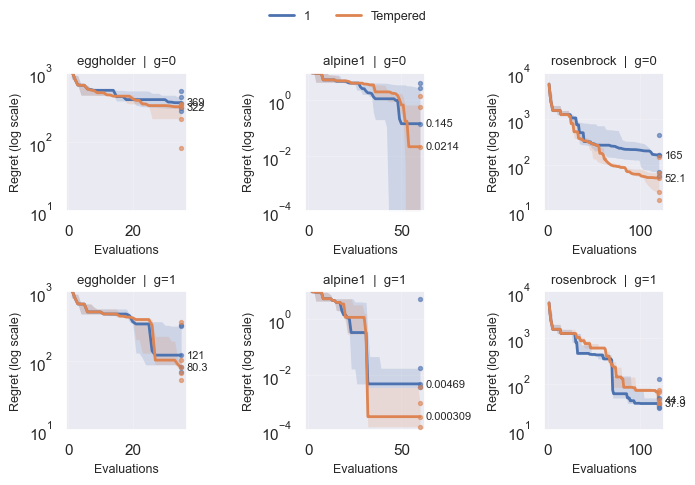

Saved: fig_log_regret_2x3.pdf


In [24]:
plot_log_regret_2x3(
    regret_dict = regret_dict,
    functions = functions_to_show,                      # list of 3 function names (columns)
    g_vals=(0, 1),                  # rows
    alpha_labels=("1", "Tempered"), # legend order & labels
    outfile="fig_log_regret_2x3.pdf",
    show=True                       # also display inline
)